<a href="https://colab.research.google.com/github/HwangJieun03/AutonomousSystem/blob/main/AutonomousSystem_Mid_term_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import cv2
from google.colab import drive

# Google Drive 마운트
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 데이터 경로 설정
BASE = '/content/drive/MyDrive/AutonomousSystem'

image_dir  = Path(BASE) / 'gray_09_image_0'
calib_path = Path(BASE) / 'calib_09' / 'calib.txt'
poses_path = Path(BASE) / 'poses_09.txt'

# 경로 확인
print("이미지 폴더 존재:", image_dir.exists())
print("calib 파일 존재:", calib_path.exists())
print("poses 파일 존재:", poses_path.exists())

이미지 폴더 존재: True
calib 파일 존재: True
poses 파일 존재: True


# 문제 1. Projection Matrix 해석
KITTI Sequence 09의 P0 (왼쪽 흑백 카메라 기준) Projection Matrix를 기준으로 해석한다.
## 1. Projection Matrix의 의미
Projection Matrix $P$는 3차원 공간의 점을 2차원 이미지 평면으로 변환하는 행렬이다.
카메라는 3D 세계를 2D 이미지로 표현하므로, 이 변환은 컴퓨터 비전에서 매우 중요하다.
Projection Matrix는 다음과 같이 표현된다.

$$P = K [R \mid t]$$

- $K$: intrinsic 파라미터 (카메라 내부 특성)
- $R, t$: extrinsic 파라미터 (카메라 위치 및 방향)

---

## 2. Intrinsic 파라미터

Intrinsic 파라미터는 카메라 자체의 특성을 나타내며, 다음과 같이 표현된다.

$$K = \begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}$$

- $f_x, f_y$: 초점 거리 (focal length) → 이미지 확대/축소 결정
- $c_x, c_y$: 주점 (principal point) → 이미지 중심 좌표

KITTI Sequence 09의 calib.txt(P0)에서 추출한 실제 값은 다음과 같다.

| 파라미터 | 값 | 의미 |
|---|---|---|
| $f_x$ | 707.0912 px | X축 초점거리 |
| $f_y$ | 707.0912 px | Y축 초점거리 |
| $c_x$ | 601.8873 px | 주점 X좌표 |
| $c_y$ | 183.1104 px | 주점 Y좌표 |

- $f_x = f_y = 707.09$ → 렌즈 보정 후 정사각형 픽셀 (비율 1:1)
- $c_x \approx 602$ → 이미지 가로(1241px) 기준 중심 근처
- $c_y \approx 183$ → 이미지 세로(376px) 기준 위쪽에 주점 위치 → 도로가 하단에 많이 찍히는 구조

---

## 3. Extrinsic 파라미터

Extrinsic 파라미터는 카메라의 위치와 방향을 나타낸다.

$$[R \mid t]$$

- $R$: 회전 행렬 → 카메라 방향
- $t$: 이동 벡터 → 카메라 위치

즉, 월드 좌표계를 카메라 좌표계로 변환하는 역할을 한다.

**스테레오 베이스라인 (P1에서 추출):**

$$t_x = \frac{-379.81}{707.09} \approx -0.537 \text{ m}$$

오른쪽 카메라(P1)는 왼쪽 카메라(P0) 기준으로 약 **53.7cm 오른쪽**에 위치한다.

**Tr 행렬 (LiDAR → Camera 변환):**

$$Tr = \begin{bmatrix} -0.001858 & -0.999966 & -0.008040 & -0.004784 \\ -0.006481 & 0.008052 & -0.999947 & -0.073374 \\ 0.999977 & -0.001806 & -0.006496 & -0.333997 \end{bmatrix}$$

- $R$ (3×3 좌측): LiDAR 좌표계를 카메라 좌표계로 회전
- $t$ (우측 열): LiDAR가 카메라보다 약 **33.4cm 앞, 7.3cm 아래** 장착

---

## 4. 3D → 2D 변환 과정

3차원 점 $\mathbf{X} = (X, Y, Z, 1)^T$ 를 Projection Matrix로 변환하면 다음과 같다.

$$\mathbf{x} = P \mathbf{X} = K [R \mid t] \mathbf{X}$$

결과는 동차좌표 $(u', v', w)$ 로 표현되며, 최종 이미지 좌표는 다음과 같이 계산된다.

$$u = \frac{f_x \cdot X}{Z} + c_x, \quad v = \frac{f_y \cdot Y}{Z} + c_y$$

Sequence 09 실제 값을 대입하면:

$$u = \frac{707.09 \cdot X}{Z} + 601.89, \quad v = \frac{707.09 \cdot Y}{Z} + 183.11$$

---

## 5. 해석

- 깊이 값 $Z$가 커질수록 $(u, v)$가 주점 $(c_x, c_y)$ 쪽으로 수렴한다.
- 이는 원근 투영(perspective projection)의 특징이다.
- 평행한 직선은 이미지에서 한 점으로 수렴하며, 이를 소실점(vanishing point)이라고 한다.
- Bayesian 분류기의 사다리꼴 ROI는 바로 이 투영 특성을 활용한 것이다.

---

## 결론

Projection Matrix는 카메라의 내부 파라미터와 외부 파라미터를 결합하여
3차원 공간의 점을 2차원 이미지로 변환하는 핵심적인 수학적 모델이다.
KITTI Sequence 09에서 $f_x = f_y = 707.09$, $c_x = 601.89$, $c_y = 183.11$ 임을 확인하였다.

# 문제 2. Projection Matrix를 이용한 3D → 2D 투영

## 1. 개요
임의의 3차원 점들을 생성하고, Projection Matrix를 이용하여
이를 2차원 이미지 좌표로 투영하였다.

---

## 2. 방법
- 카메라 전방에 임의의 3D 점 50개 생성 (Z: 5~50m)
- calib.txt에서 로드한 P0 행렬로 2D 투영
- 깊이(Z값)에 따라 색상을 달리하여 이미지 위에 시각화

fx=707.0912, fy=707.0912, cx=601.8873, cy=183.1104
P0 =
 [[707.0912   0.     601.8873   0.    ]
 [  0.     707.0912 183.1104   0.    ]
 [  0.       0.       1.       0.    ]]


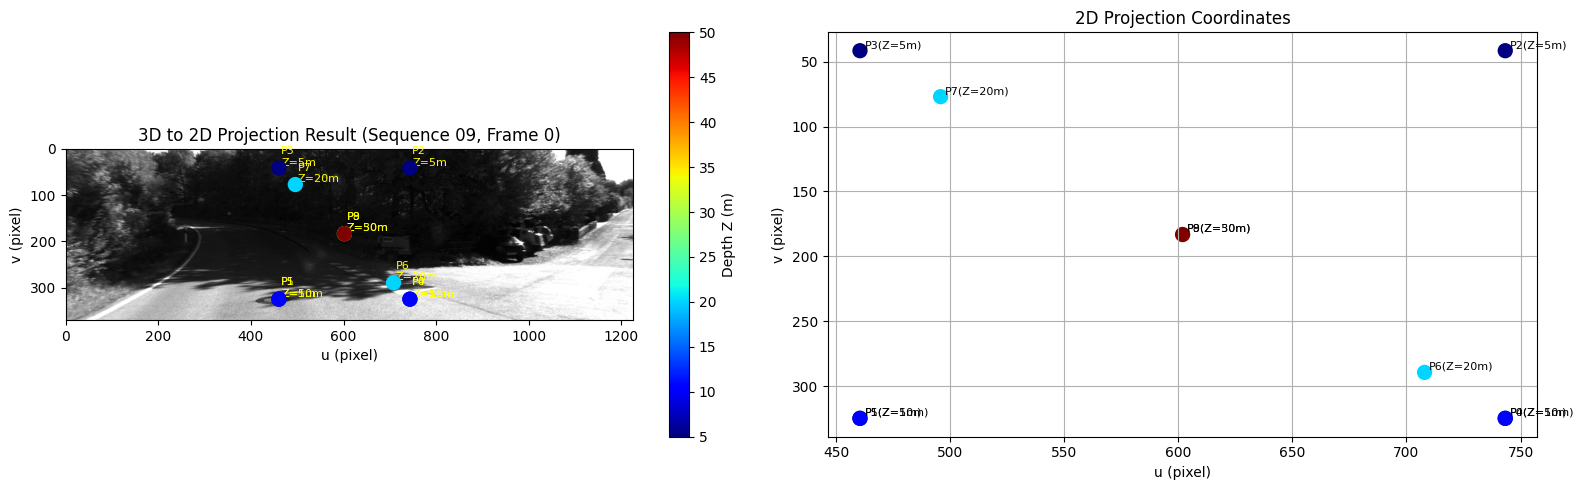

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# -------------------------
# 1. calib.txt에서 P0 로드
# -------------------------
def load_calib(calib_path):
    with open(calib_path, 'r') as f:
        for line in f:
            if line.startswith('P0:'):
                vals = list(map(float, line.strip().split()[1:]))
                return np.array(vals).reshape(3, 4)

P0 = load_calib(calib_path)

# Intrinsic 파라미터 추출
fx = P0[0, 0]  # 707.0912
fy = P0[1, 1]  # 707.0912
cx = P0[0, 2]  # 601.8873
cy = P0[1, 2]  # 183.1104

print(f"fx={fx:.4f}, fy={fy:.4f}, cx={cx:.4f}, cy={cy:.4f}")
print("P0 =\n", P0)

# -------------------------
# 2. P0를 Projection Matrix로 사용
# -------------------------
P = P0  # calib.txt에서 로드한 실제 Projection Matrix 사용

# -------------------------
# 3. 3D 점 생성
# -------------------------
points_3d = np.array([
    [ 1,  1,  5, 1],
    [-1,  1,  5, 1],
    [ 1, -1,  5, 1],
    [-1, -1,  5, 1],
    [ 2,  2, 10, 1],
    [-2,  2, 10, 1],
    [ 3,  3, 20, 1],
    [-3, -3, 20, 1],
    [ 0,  0, 30, 1],
    [ 0,  0, 50, 1],
])

# -------------------------
# 4. Projection 수행
# -------------------------
points_2d_h = P @ points_3d.T
points_2d_h /= points_2d_h[2]
u = points_2d_h[0]
v = points_2d_h[1]

# -------------------------
# 5. 실제 이미지 위에 시각화
# -------------------------
frames = sorted(Path(image_dir).glob("*.png"))
img = np.array(Image.open(frames[0]))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 왼쪽: 실제 이미지 위에 투영
axes[0].imshow(img, cmap='gray')
depths = [p[2] for p in points_3d]
sc = axes[0].scatter(u, v, c=depths, cmap='jet', s=100, zorder=5)
for i in range(len(u)):
    axes[0].text(u[i]+5, v[i]-5, f"P{i}\nZ={points_3d[i][2]}m",
                 color='yellow', fontsize=8)
plt.colorbar(sc, ax=axes[0], label='Depth Z (m)')
axes[0].set_title('3D to 2D Projection Result (Sequence 09, Frame 0)')
axes[0].set_xlim(0, img.shape[1])
axes[0].set_ylim(img.shape[0], 0)
axes[0].set_xlabel('u (pixel)')
axes[0].set_ylabel('v (pixel)')

# 오른쪽: 투영 좌표만 시각화
axes[1].scatter(u, v, c=depths, cmap='jet', s=100)
for i in range(len(u)):
    axes[1].text(u[i]+2, v[i]-2, f"P{i}(Z={points_3d[i][2]}m)", fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title('2D Projection Coordinates')
axes[1].set_xlabel('u (pixel)')
axes[1].set_ylabel('v (pixel)')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('problem2_projection.png', dpi=150)
plt.show()

## 3. 결과 해석

본 실험에서는 KITTI dataset의 calibration 정보를 이용하여 Projection Matrix를 구성하고,
이를 통해 3차원 점이 실제 카메라 이미지 상에 어떻게 투영되는지 확인하였다.

실험 결과, 깊이(Z)가 증가할수록 점들이 이미지 중심 방향으로 수렴하는
원근 투영(perspective projection)의 특성을 확인할 수 있었다.
특히 가까운 점(Z=5m)은 이미지 상에서 넓게 퍼져 나타나고,
멀리 있는 점(Z=50m)은 주점(cx=601.89, cy=183.11) 근처로 집중되는 경향을 보였다.

이는 실제 카메라 모델에서 나타나는 원근 효과와 일치하는 결과로,
Projection Matrix가 3D 공간 정보를 2D 이미지로 변환하는 과정을
정확하게 반영하고 있음을 확인할 수 있다.

# 문제 3. Pose를 이용한 차량 궤적 시각화

## 1. 개요
KITTI dataset의 pose 데이터를 이용하여 차량(카메라)의 이동 궤적을 시각화하였다.
각 프레임마다 카메라의 위치를 추출하여 2차원 평면 상에 표시하였다.

---

## 2. 방법
- poses.txt 파일에서 각 프레임의 변환 행렬을 불러온다
- 각 행렬에서 translation (위치) 정보를 추출한다
- (x, z) 좌표를 이용하여 궤적을 시각화한다

Total frames: 1591
First pose:
 [[1.000000e+00 1.197625e-11 1.704638e-10 5.551115e-17]
 [1.197625e-11 1.000000e+00 3.562503e-10 0.000000e+00]
 [1.704638e-10 3.562503e-10 1.000000e+00 2.220446e-16]]


/tmp/ipykernel_32270/1607763736.py:62: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_32270/1607763736.py:63: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('problem3_trajectory.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


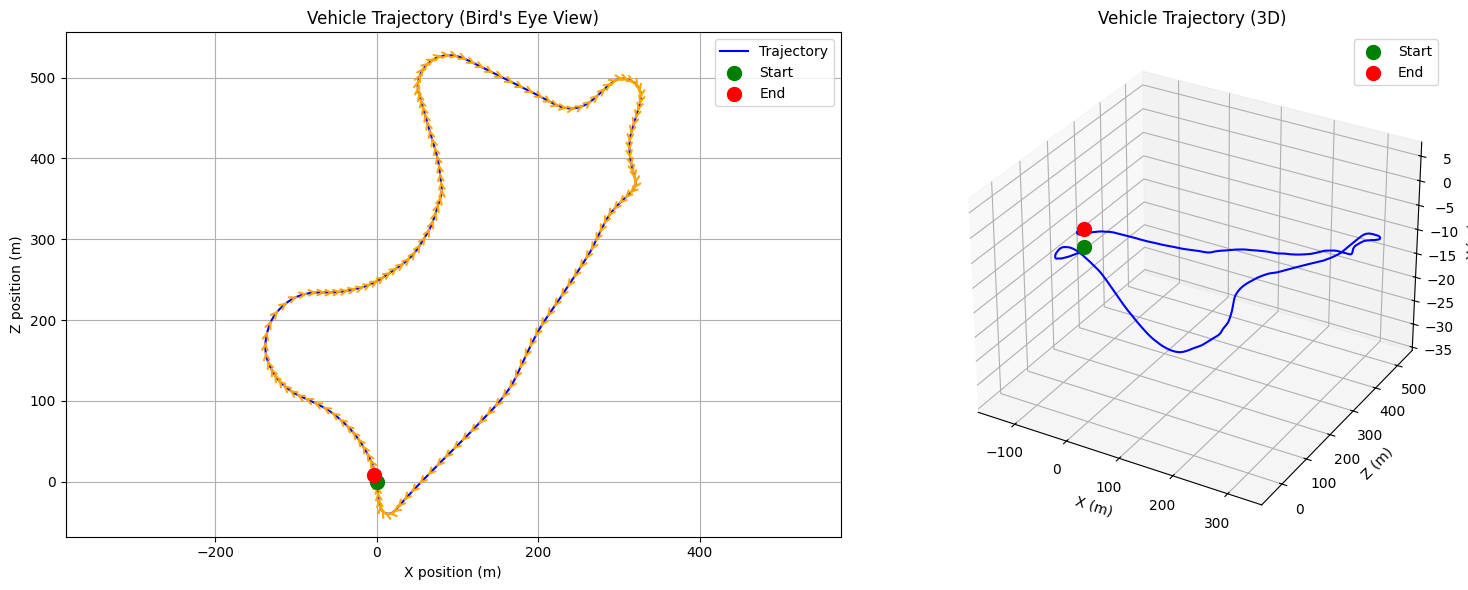


Total distance: 1702.46 m
Average distance per frame: 1.0707 m
Max distance per frame: 1.5355 m
Min distance per frame: 0.2889 m


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -------------------------
# 1. poses 로드
# -------------------------
poses = []
with open(poses_path, 'r') as f:
    for line in f:
        vals = list(map(float, line.strip().split()))
        pose = np.array(vals).reshape(3, 4)
        poses.append(pose)

print(f"Total frames: {len(poses)}")
print("First pose:\n", poses[0])

# -------------------------
# 2. 위치 추출 (x, y, z)
# -------------------------
positions = np.array([[p[0,3], p[1,3], p[2,3]] for p in poses])
x = positions[:, 0]
y = positions[:, 1]
z = positions[:, 2]

# -------------------------
# 3. 시각화
# -------------------------
fig = plt.figure(figsize=(16, 6))

# 왼쪽: 2D 궤적 (Bird's Eye View)
ax1 = fig.add_subplot(121)
ax1.plot(x, z, 'b-', linewidth=1.5, label='Trajectory')
ax1.scatter(x[0], z[0], c='green', s=100, zorder=5, label='Start')
ax1.scatter(x[-1], z[-1], c='red', s=100, zorder=5, label='End')

# 10프레임마다 방향 화살표
for i in range(0, len(poses)-1, 10):
    dx = x[i+1] - x[i]
    dz = z[i+1] - z[i]
    ax1.annotate('', xy=(x[i+1], z[i+1]), xytext=(x[i], z[i]),
                 arrowprops=dict(arrowstyle='->', color='orange', lw=1.5))

ax1.set_title("Vehicle Trajectory (Bird's Eye View)")
ax1.set_xlabel("X position (m)")
ax1.set_ylabel("Z position (m)")
ax1.legend()
ax1.grid(True)
ax1.axis('equal')

# 오른쪽: 3D 궤적
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(x, z, y, 'b-', linewidth=1.5)
ax2.scatter(x[0], z[0], y[0], c='green', s=100, label='Start')
ax2.scatter(x[-1], z[-1], y[-1], c='red', s=100, label='End')
ax2.set_title('Vehicle Trajectory (3D)')
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Z (m)')
ax2.set_zlabel('Y (m)')
ax2.legend()

plt.tight_layout()
plt.savefig('problem3_trajectory.png', dpi=150)
plt.show()

# -------------------------
# 4. 속도 분석
# -------------------------
distances = np.sqrt(np.diff(x)**2 + np.diff(z)**2)
print(f"\nTotal distance: {distances.sum():.2f} m")
print(f"Average distance per frame: {distances.mean():.4f} m")
print(f"Max distance per frame: {distances.max():.4f} m")
print(f"Min distance per frame: {distances.min():.4f} m")

## 3. 결과 해석

- 총 1591 프레임에 걸쳐 약 1702.46 m를 이동하였다.
- 차량은 출발점(초록색)에서 시작하여 루프(loop) 형태의 경로를 따라 이동한 후,
  초기 위치 근처로 복귀하는 경향을 보인다.
- 3D 궤적에서 Y축(높이) 변화가 거의 없는 것으로 보아,
  차량이 평탄한 도로 환경에서 주행하였음을 확인할 수 있다.

## 4. 속도 및 이동 분석

- 프레임 간 이동 거리를 계산한 결과, 평균 1.0707 m,
  최대 1.5355 m, 최소 0.2889 m로 나타났다.
- 이는 차량이 일정한 속도로만 이동하는 것이 아니라,
  가속 및 감속 구간이 존재함을 의미한다.
- 직선 구간에서는 이동 방향이 일정하며,
  시각화된 화살표 또한 일정한 방향성을 유지한다.
- 반면 곡선 구간에서는 이동 방향이 변화하며,
  이는 차량의 회전 및 방향 전환을 나타낸다.

따라서 pose 데이터는 차량의 위치뿐만 아니라
이동 방향과 속도까지 분석할 수 있는 중요한 정보임을 확인할 수 있다.

# 문제 4. Projection Matrix를 활용한 차선 해석

## 1. 개요

본 실험에서는 Bayesian 분류를 이용하여 도로 영역을 추정하고,
해당 영역에서 차선 후보를 추출한 뒤,
이를 Projection Matrix와 연관 지어 해석하였다.

특히, 단순한 이미지 처리 결과를 넘어서
차선이 3차원 도로 구조에서 어떻게 형성되고,
카메라 투영 과정에서 어떤 형태로 나타나는지를 분석하는 데 목적이 있다.

---

## 2. 방법

본 실험은 다음과 같은 과정으로 진행하였다.

1. 도로 영역 추정  
   이미지에서 도로가 존재할 가능성이 높은 영역을 사다리꼴 형태로 정의하고,
   해당 영역을 기반으로 Bayesian 분류를 수행하여 도로 마스크를 생성하였다.

2. 확률 기반 분류  
   도로 영역과 배경 영역에서 픽셀 밝기 히스토그램을 계산하고,
   이를 이용하여 각 픽셀이 도로일 확률과 배경일 확률을 비교하였다.
   이때 도로와 배경의 사전확률(prior)은 동일하게 설정하였다.

3. 차선 후보 추출  
   생성된 도로 마스크에 대해 Canny edge detection을 적용한 후,
   Hough Transform을 이용하여 직선 형태의 차선 후보를 검출하였다. 추가적으로 차선 검출의 정확도를 높이기 위해 이미지 하단 영역(ROI)만을 사용하였으며,
   morphological operation(열림/닫힘 연산)을 적용하여 노이즈를 제거하고
   도로 영역을 보다 안정적으로 추출하였다.

4. Projection 기반 해석  
   검출된 차선 후보를 Projection Matrix 관점에서 해석하여,
   이미지 상의 직선이 실제 3차원 도로 구조와 어떤 관계를 가지는지 분석하였다.

검출된 차선 수: 10


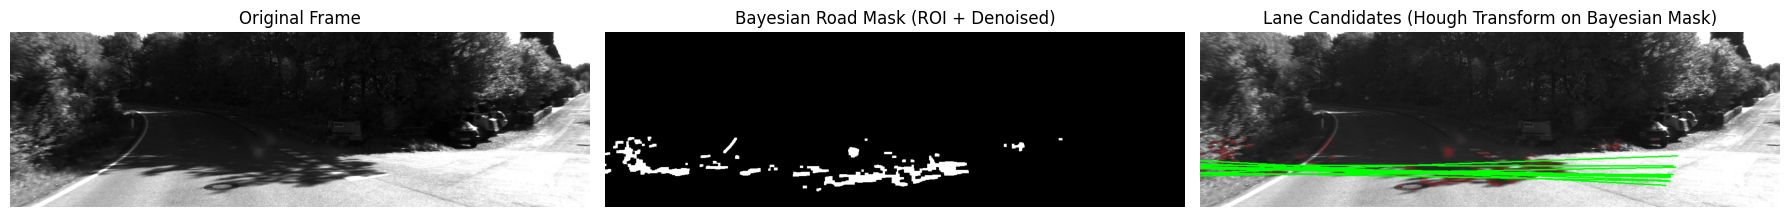

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
from pathlib import Path
from PIL import Image

# -------------------------
# 1. Bayesian 분류기로 도로 마스크 생성
# -------------------------
def get_trapezoid_mask(width, height, vp_y_rate=0.5, bottom_width_rate=0.9, top_width_rate=0.15):
    mask = np.zeros((height, width), dtype=np.uint8)
    vp_y = int(height * vp_y_rate)
    p1 = [int(width * (0.5 - top_width_rate)), vp_y]
    p2 = [int(width * (0.5 + top_width_rate)), vp_y]
    p3 = [int(width * (0.5 + bottom_width_rate/2)), height]
    p4 = [int(width * (0.5 - bottom_width_rate/2)), height]
    pts = np.array([p1, p2, p3, p4], np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask

frames = sorted(Path(image_dir).glob("*.png"))
sample = np.array(Image.open(frames[0]), dtype=np.uint8)
h, w = sample.shape

road_mask = get_trapezoid_mask(w, h)
bg_mask = 1 - road_mask

road_hist = np.ones(256)
bg_hist = np.ones(256)
alpha = 0.85

for i, path in enumerate(frames[:50]):
    img_arr = np.array(Image.open(path), dtype=np.uint8)
    curr_road = np.bincount(img_arr[road_mask > 0].flatten(), minlength=256).astype(np.float64)
    curr_bg = np.bincount(img_arr[bg_mask > 0].flatten(), minlength=256).astype(np.float64)
    if i == 0:
        road_hist = curr_road + 1
        bg_hist = curr_bg + 1
    else:
        road_hist = alpha * road_hist + (1 - alpha) * (curr_road + 1)
        bg_hist = alpha * bg_hist + (1 - alpha) * (curr_bg + 1)

road_p = road_hist / road_hist.sum()
bg_p = bg_hist / bg_hist.sum()

img = np.array(Image.open(frames[0]), dtype=np.uint8)
eps = 1e-10
log_road = np.log(road_p[img] + eps) + math.log(0.5)
log_bg = np.log(bg_p[img] + eps) + math.log(0.5)
bayes_mask = (log_road > log_bg).astype(np.uint8) * 255

# -------------------------
# 2. 하단 ROI만 사용 + 노이즈 제거
# -------------------------
roi_mask = np.zeros_like(bayes_mask)
roi_mask[int(h*0.6):, :] = 1          # 하단 40%만 사용
bayes_roi = cv2.bitwise_and(bayes_mask, bayes_mask, mask=roi_mask)

kernel = np.ones((5,5), np.uint8)
bayes_clean = cv2.morphologyEx(bayes_roi, cv2.MORPH_OPEN, kernel)
bayes_clean = cv2.morphologyEx(bayes_clean, cv2.MORPH_CLOSE, kernel)

# -------------------------
# 3. Hough Transform
# -------------------------
edges = cv2.Canny(bayes_clean, 30, 100)
lines = cv2.HoughLines(edges, 1, np.pi/180, 80)

img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
overlay = img_color.copy()
overlay[bayes_clean > 0] = [0, 0, 180]
img_color = cv2.addWeighted(img_color, 0.7, overlay, 0.3, 0)

if lines is not None:
    print(f"검출된 차선 수: {len(lines)}")
    for line in lines[:10]:
        rho, theta = line[0]
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a*rho, b*rho
        x1 = int(x0 + 1000*(-b))
        y1 = int(y0 + 1000*(a))
        x2 = int(x0 - 1000*(-b))
        y2 = int(y0 - 1000*(a))
        cv2.line(img_color, (x1,y1), (x2,y2), (0,255,0), 2)
else:
    print("차선 미검출")

# -------------------------
# 4. 시각화
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Frame')
axes[0].axis('off')

axes[1].imshow(bayes_clean, cmap='gray')
axes[1].set_title('Bayesian Road Mask (ROI + Denoised)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
axes[2].set_title('Lane Candidates (Hough Transform on Bayesian Mask)')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('problem4_lane.png', dpi=150)
plt.show()

## 3. 결과 해석

### 이미지 좌표에서 검출된 차선의 의미
검출된 차선은 이미지 좌표계에서 직선으로 나타나며, 이는 카메라 좌표계에서
도로 평면 위의 3차원 직선이 투영된 결과이다.
Projection Matrix에 의해 Z가 증가할수록 직선이 소실점(cx=601.89, cy=183.11)
방향으로 수렴하는 특성을 보인다.

### 도로 평면(Ground Plane) 가정
도로가 평면이라고 가정하면, 차선은 Y=0 평면 위의 직선으로 표현된다.
이 경우 투영된 차선은 이미지 상에서 소실점을 향해 수렴하는 직선으로 나타나며,
이는 Hough Transform으로 검출된 결과와 일치한다.

### Projection Matrix와 소실점의 관계
평행한 두 차선은 3차원 공간에서는 만나지 않지만,
Projection Matrix에 의해 2D 이미지로 투영되면 소실점에서 만나게 된다.
소실점의 위치는 카메라의 주점(cx, cy) 및 초점거리(fx, fy)에 의해 결정되며,
이는 Projection Matrix의 intrinsic 파라미터와 직접적으로 연관된다.

# 문제 5. 실패 구간 분석

## 1. 개요
Bayesian 분류기를 이용한 차선 검출 결과를 분석한 결과,
일부 프레임에서 도로 영역이 제대로 검출되지 않거나
차선 검출이 불안정하게 나타나는 구간이 존재하였다.
본 실험에서는 각 프레임의 도로 검출 비율을 정량적으로 계산하여
실패 구간을 자동으로 추출하고, 그 원인을 분석하였다.

---

## 2. 방법
1. 도로 검출 비율 계산  
   각 프레임에서 Bayesian 분류기를 적용하여
   ROI 영역 내 도로로 분류된 픽셀 비율을 계산하였다.

2. 실패 구간 정의  
   도로 검출 비율이 하위 15%에 해당하는 프레임을
   실패 구간으로 정의하였다.

3. 시각화  
   실패 구간의 원본 프레임과 Bayesian 마스크를 시각화하고,
   차량 궤적 상에서 해당 위치를 표시하였다.

실패 구간 프레임 번호: [0, 5, 140, 170, 175]
도로 검출 비율 평균: 0.5560
실패 구간 임계값: 0.2309


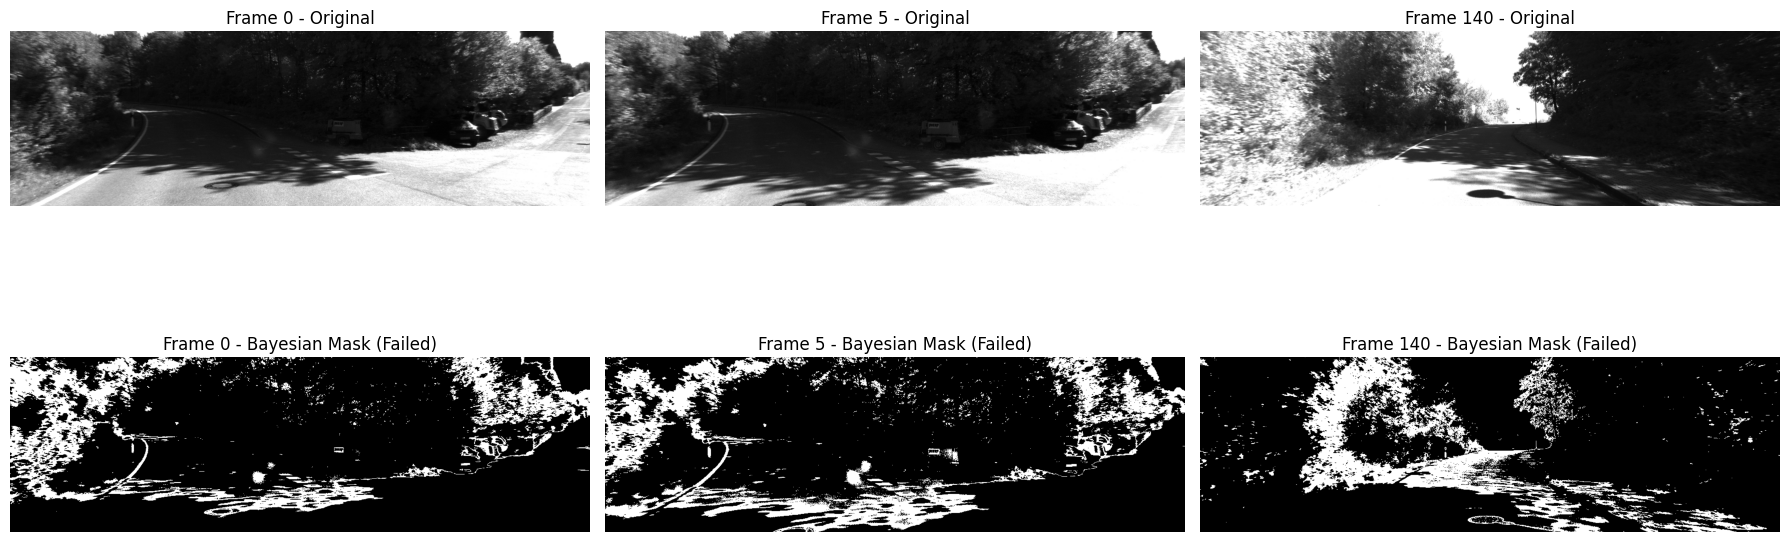

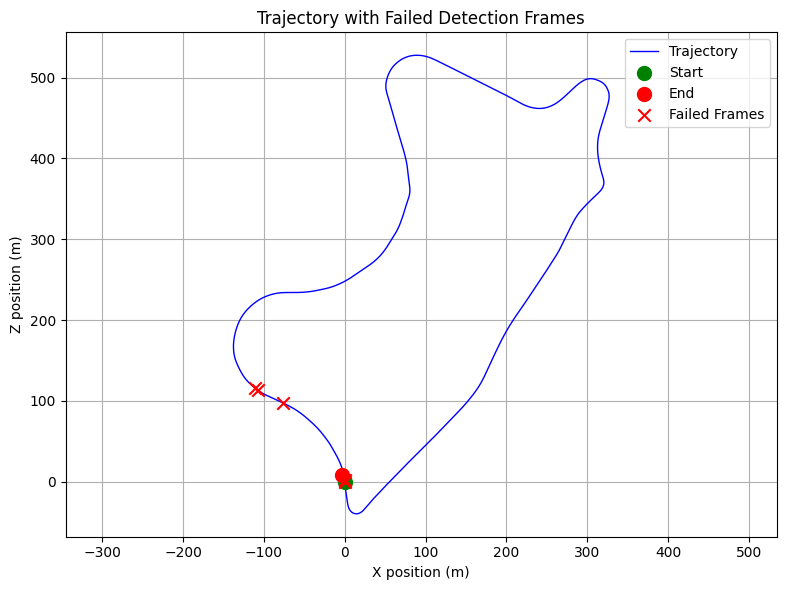

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
from pathlib import Path
from PIL import Image

# -------------------------
# 1. 여러 프레임에 Bayesian 분류 적용 → 도로 검출 비율 계산
# -------------------------
frames = sorted(Path(image_dir).glob("*.png"))

road_ratios = []
sample_indices = list(range(0, min(300, len(frames)), 5))  # 5프레임마다 샘플링

for idx in sample_indices:
    img = np.array(Image.open(frames[idx]), dtype=np.uint8)
    eps = 1e-10
    log_road = np.log(road_p[img] + eps) + math.log(0.5)
    log_bg = np.log(bg_p[img] + eps) + math.log(0.5)
    mask = (log_road > log_bg).astype(np.uint8)

    # ROI 하단만
    roi = np.zeros_like(mask)
    roi[int(h*0.6):, :] = 1
    mask_roi = mask * roi

    ratio = mask_roi.sum() / roi.sum()
    road_ratios.append(ratio)

road_ratios = np.array(road_ratios)

# -------------------------
# 2. 실패 구간 찾기 (도로 검출 비율 낮은 구간)
# -------------------------
threshold = np.percentile(road_ratios, 15)  # 하위 15%
fail_indices = [sample_indices[i] for i, r in enumerate(road_ratios) if r < threshold]

print(f"실패 구간 프레임 번호: {fail_indices[:5]}")
print(f"도로 검출 비율 평균: {road_ratios.mean():.4f}")
print(f"실패 구간 임계값: {threshold:.4f}")

# -------------------------
# 3. 실패 구간 시각화
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, idx in enumerate(fail_indices[:3]):
    img = np.array(Image.open(frames[idx]), dtype=np.uint8)
    log_road = np.log(road_p[img] + eps) + math.log(0.5)
    log_bg = np.log(bg_p[img] + eps) + math.log(0.5)
    mask = (log_road > log_bg).astype(np.uint8) * 255

    axes[0][i].imshow(img, cmap='gray')
    axes[0][i].set_title(f'Frame {idx} - Original')
    axes[0][i].axis('off')

    axes[1][i].imshow(mask, cmap='gray')
    axes[1][i].set_title(f'Frame {idx} - Bayesian Mask (Failed)')
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig('problem5_fail.png', dpi=150)
plt.show()

# -------------------------
# 4. 궤적에서 실패 구간 표시
# -------------------------
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, z, 'b-', linewidth=1, label='Trajectory')
ax.scatter(x[0], z[0], c='green', s=100, zorder=5, label='Start')
ax.scatter(x[-1], z[-1], c='red', s=100, zorder=5, label='End')

for idx in fail_indices[:5]:
    ax.scatter(x[idx], z[idx], c='red', s=80, marker='x', zorder=6)

ax.scatter([], [], c='red', marker='x', s=80, label='Failed Frames')
ax.set_title("Trajectory with Failed Detection Frames")
ax.set_xlabel("X position (m)")
ax.set_ylabel("Z position (m)")
ax.legend()
ax.grid(True)
ax.axis('equal')
plt.tight_layout()
plt.savefig('problem5_trajectory_fail.png', dpi=150)
plt.show()

## 3. 실패 구간 선정
도로 검출 비율을 분석한 결과, 도로 검출 비율 평균은 0.5560이었으며,
하위 15% 임계값인 0.2309 미만의 프레임을 실패 구간으로 정의하였다.
그 결과 Frame 0, 5, 140, 170, 175 등에서 차선 검출이 제대로 이루어지지 않음을 확인하였다.

---

## 4. 궤적 상 위치
실패 프레임들을 차량 궤적 위에 표시한 결과,
실패 구간은 주로 출발점 근처 및 초반 주행 구간에 집중되어 있었다.
이는 초반 프레임에서 Bayesian 분류기가 아직 충분한 통계 정보를 학습하지 못한 상태이며,
시계열 일관성(alpha=0.85)이 안정화되기 전이기 때문으로 해석할 수 있다.

---

## 5. 실패 원인 분석

### (1) 조명 변화 및 그림자
Frame 0, 5에서 도로 위에 짙은 그림자가 존재하여
Bayesian 분류에서 사용하는 픽셀 밝기 분포가 실제 도로와 다르게 나타났다.
이로 인해 도로 영역이 일부 배경으로 잘못 분류되는 문제가 발생하였다.

### (2) 도로 질감 변화
Frame 140에서 도로 표면의 밝기가 주변 배경과 유사하여
배경이 도로로 잘못 분류되거나 도로가 배경으로 분류되는 문제가 발생하였다.

### (3) 차량의 회전 및 시점 변화
곡선 구간에서는 차량이 회전하면서 카메라 시점이 변화하게 된다.
이로 인해 차선의 기울기가 급격하게 변하고,
Hough Transform에서 직선 검출이 불안정해질 수 있다.

### (4) ROI(사다리꼴 가정)의 한계
본 실험에서는 도로가 특정 ROI 내에 존재한다고 가정하였다.
그러나 실제 환경에서는 차선이 ROI를 벗어나거나
도로 형태가 변형되는 경우가 발생할 수 있으며,
이로 인해 차선 검출이 실패할 수 있다.

---

## 6. 결론
차선 검출 실패는 주로 조명 변화, 도로 환경 변화, 차량의 움직임,
그리고 ROI 가정의 한계에서 발생하였다.
본 실험을 통해 단순한 확률 기반 방법의 한계를 확인할 수 있었으며,
보다 안정적인 차선 검출을 위해서는 환경 변화에 강건한 모델이 필요함을 알 수 있었다.

# 문제 6. 딥러닝 기반 차선 검출 모델 비교 (Segformer)

## 1. 모델 선정
차선 및 도로 영역 분할을 위한 딥러닝 모델로 Segformer를 선정하였다.
Segformer는 transformer 기반의 semantic segmentation 모델로,
계층적 구조를 통해 다양한 해상도의 특징을 추출하며
경량화된 decoder로 효율적인 추론이 가능하다.
특히 Cityscapes 데이터셋으로 학습된 pretrained 모델을 사용하여
별도의 학습 없이 도로 영역을 분할할 수 있다.
Cityscapes 데이터셋은 자율주행 환경의 도로 장면을 포함하고 있어,
KITTI 데이터셋과 유사한 특성을 가지므로 보다 적합한 비교가 가능하다.

---

## 2. 기존 방법과의 차이
본 과제에서 사용한 Bayesian 기반 방법은
픽셀 밝기 분포를 기반으로 도로 영역을 분류하는 방식이다.
반면 Segformer는 다음과 같은 특징을 가진다.
- 픽셀의 밝기뿐만 아니라 주변 패턴과 구조를 함께 고려
- transformer 구조로 이미지의 전역적 문맥(context)을 반영
- 다양한 환경 변화에 대해 강건한 성능 제공

---

## 3. 실험 방법
코랩 환경에서 Cityscapes pretrained Segformer 모델을 이용하여
KITTI dataset의 프레임에 대해 segmentation을 수행하였다.
출력된 segmentation 결과에서 도로에 해당하는 클래스를 기준으로
도로 영역을 추출하여 Bayesian 기반 도로 검출 결과와 비교하였다.


In [ ]:
from transformers import pipeline
from PIL import Image
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
import os
os.environ['TQDM_DISABLE'] = '1'

import transformers
transformers.logging.set_verbosity_error()

# 1. 모델 로드
segmenter = pipeline("image-segmentation",
                     model="nvidia/segformer-b0-finetuned-cityscapes-512-1024", device=0)

# 2. 프레임 로드
frames = sorted(Path(image_dir).glob("*.png"))
img_pil = Image.open(frames[500]).convert('RGB')

# 3. 추론
results = segmenter(img_pil)

# 4. road 마스크 추출
road_mask_dl = np.zeros((img_pil.size[1], img_pil.size[0]), dtype=np.uint8)
for r in results:
    if r['label'].lower() == 'road':
        road_mask_dl = np.array(r['mask'])
        break

print(f"검출된 클래스: {[r['label'] for r in results]}")

# 5. Bayesian 마스크 생성
img_arr = np.array(Image.open(frames[500]).convert('L'), dtype=np.uint8)
log_road = np.log(road_p[img_arr] + 1e-10) + math.log(0.5)
log_bg = np.log(bg_p[img_arr] + 1e-10) + math.log(0.5)
bayes_mask_comp = (log_road > log_bg).astype(np.uint8) * 255

# 6. 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img_pil)
axes[0].set_title('Original Frame')
axes[0].axis('off')

axes[1].imshow(bayes_mask_comp, cmap='gray')
axes[1].set_title('Bayesian Road Mask')
axes[1].axis('off')

axes[2].imshow(road_mask_dl, cmap='gray')
axes[2].set_title('Segformer Road Segmentation (Cityscapes)')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('problem6_comparison.png', dpi=150)
plt.show()

## 4. 결과 비교

### (1) Bayesian 기반 방법
- 단순한 환경에서는 도로 영역을 비교적 검출하나 노이즈가 존재함
- 조명 변화(그림자, 밝기 변화)에 민감하여 나무, 건물 등이
  도로로 잘못 분류되는 경우가 발생함
- ROI 가정에 의존적이며 복잡한 도로 환경에서 성능 저하 발생

### (2) Segformer 기반 방법
- 전반적으로 도로 영역이 보다 안정적으로 분할되는 경향을 보임
- 차량, 건물 등 주변 객체와 도로를 구분하는 능력이 향상됨
- Cityscapes 기반 학습으로 도로 주행 환경에 보다 적합한 결과를 보임

---

## 5. 결론

Segformer와 같은 딥러닝 기반 모델은 기존의 확률 기반 방법보다
전반적으로 높은 정확도와 안정성을 제공하는 경향을 보였다.

특히 조명 변화나 복잡한 환경에서도 보다 일관된 결과를 나타내었으며,
이는 단순한 밝기 기반 분류보다 이미지의 구조적 특징을 학습한 결과로 볼 수 있다.

따라서 실제 자율주행 시스템에서는 Bayesian과 같은 단순 모델보다
Segformer와 같은 딥러닝 기반 segmentation 모델이
더 효과적인 접근 방법임을 확인할 수 있었다.

In [8]:
# widgets 메타데이터 제거
import json

notebook_path = '/content/drive/MyDrive/Colab Notebooks/AutonomousSystem_Mid-term Report.ipynb'

with open(notebook_path, 'r') as f:
    nb = json.load(f)

if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']

with open(notebook_path, 'w') as f:
    json.dump(nb, f)

print("완료!")

완료!
